## Power spectral density using Welch's method for one-sided spectrum

1. Split signal into overlapping segments of length NFFT
2. Detrend each segment
3. Apply window (length NFFT!)
4. Zero-pad (>= NFFT, power of 2)
5. Compute FFT
6. Keep only positive frequencies (one-sided spectrum)
7. Apply proper normalization (window + Fs + one-sided scaling)

In [31]:
#--------------------------------------------------------------------------------------------
from pylab import *
import numpy as np
import types

#----------------------------------------------------------------    
def apply_window(x, window):
    """
    Apply a window to signal x.

    'window' can be:
    1. A function: window(x) returns a windowed version of x
    2. An array: same shape as x, applied multiplicatively

    In DSP terms:
    x_w[n] = x[n] * w[n]
    """
    if type(window) == types.FunctionType:
        # Window is a function that internally applies the weighting
        return window(x)
    else:
        # Window is an array → pointwise multiplication
        return window * x


#----------------------------------------------------------------    
def _spectral_helper(x, NFFT=256, Fs=2, detrend=detrend_none,
                 window=window_hanning, noverlap=0, pad_to=None):

    """
    Compute windowed, segmented FFT slices of a signal.

    This is a low-level routine used in spectral estimation (e.g. Welch PSD).

    Pipeline:
    1. Split signal into overlapping segments of length NFFT
    2. Detrend each segment
    3. Apply window (length NFFT!)
    4. Zero-pad to length pad_to (>= NFFT, power of 2)
    5. Compute FFT
    6. Keep only positive frequencies (one-sided spectrum)
    7. Apply proper normalization (window + Fs + one-sided scaling)

    Returns:
    - FFTSlices: normalized complex spectra (per segment)
    - freqs: frequency axis (0 → Fs/2)
    """

    # Original signal length
    n = len(x)

    #------------------------------------------------------------
    # Ensure we have at least one full segment
    #------------------------------------------------------------
    if len(x) < NFFT:
        # Resize to NFFT and zero-pad the rest
        x = np.resize(x, (NFFT,))
        x[n:] = 0
        # NOTE: np.resize may repeat data, but we overwrite with zeros

    #------------------------------------------------------------
    # FFT length selection
    #------------------------------------------------------------
    if pad_to is None:
        pad_to = NFFT

    # Force FFT length to next power of 2 (computational efficiency)
    pad_to = 2**int(np.ceil(np.log2(pad_to)))

    # Number of frequencies in one-sided spectrum
    # (DC → Nyquist)
    numFreqs = pad_to // 2 + 1

    #------------------------------------------------------------
    # Segment indexing (overlapping windows)
    #------------------------------------------------------------
    # Step size = hop = NFFT - noverlap
    ind = list(range(0, n - NFFT + 1, NFFT - noverlap))

    # Number of segments
    numSlices = len(ind)

    # Allocate array:
    # rows → time segments
    # cols → frequency bins
    FFTSlices = np.zeros((numSlices, numFreqs), dtype=np.complex_)

    # Simple list of indices for looping
    slices = list(range(numSlices))

    #------------------------------------------------------------
    # Window normalization (VERY IMPORTANT)
    #------------------------------------------------------------
    # Apply window to a constant signal of ones → yields window itself
    # Then compute L2 norm:
    # normVal = sqrt(sum w[n]^2)
    #
    # This ensures energy normalization:
    # compensates for attenuation introduced by the window
    normVal = np.linalg.norm(apply_window(np.ones(NFFT), window))

    #------------------------------------------------------------
    # Main loop: process each segment
    #------------------------------------------------------------
    for iSlice in slices:

        # Extract segment of length NFFT
        segment = x[ind[iSlice]:ind[iSlice] + NFFT]

        # Remove mean / trend if needed
        segment = detrend(segment)

        # Apply window (length NFFT!)
        segment = apply_window(segment, window)

        # Compute FFT:
        # - zero-padded to length pad_to
        # - gives finer frequency grid (interpolation), not higher resolution
        spectrum = np.fft.fft(segment, n=pad_to)

        # Keep only positive frequencies (one-sided spectrum)
        FFTSlices[iSlice, :] = spectrum[:numFreqs]

    #------------------------------------------------------------
    # Frequency axis
    #------------------------------------------------------------
    # f_k = k * Fs / pad_to
    freqs = float(Fs) / pad_to * np.arange(numFreqs)

    #------------------------------------------------------------
    # One-sided spectrum correction
    #------------------------------------------------------------
    # We removed negative frequencies.
    # For real signals:
    # |X(-f)|^2 = |X(f)|^2
    #
    # To preserve total energy:
    # double the power of interior bins
    # → multiply amplitudes by sqrt(2)
    #
    # DO NOT scale:
    # - DC (index 0)
    # - Nyquist (last index)
    FFTSlices[:, 1:-1] *= np.sqrt(2)

    #------------------------------------------------------------
    # Final normalization
    #------------------------------------------------------------
    # Divide by:
    # 1. normVal → window energy normalization
    # 2. sqrt(Fs) → ensures PSD units (V^2 / Hz after squaring)
    #
    # After this:
    # |FFTSlices|^2 behaves like a properly scaled PSD contribution
    return FFTSlices / normVal / np.sqrt(Fs), freqs

    #------------------------------------------------------------
    # NOTE (commented original line):
    # Pxx = mean(|Slices|^2)
    #
    # This function returns the building blocks for PSD:
    # averaging over slices is done outside
    #------------------------------------------------------------

#--------------------------------------------------------------------------------------------
def psd(x, NFFT=256, Fs=2, detrend=detrend_none, window=window_hanning, noverlap=0, pad_to=None):
    X, f =     _spectral_helper(x, NFFT, Fs, detrend, window, noverlap, pad_to)
    Pxx = np.abs(X)**2
    return Pxx.mean(axis=0), f

In [32]:
from scipy.io import wavfile
import scipy.io
samplerate, data = wavfile.read("02. School Boy-9.wav")
print(samplerate, data.shape)

44100 (882000, 2)


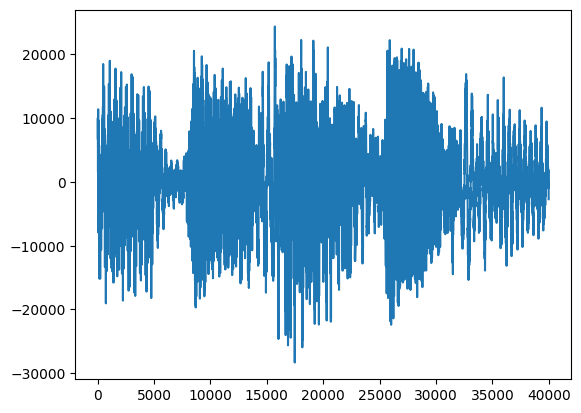

In [33]:
plot(data[10000:50000, 0])

array([1.31055091e+01, 2.39932355e+01, 2.48665133e+01, ...,
       3.85225117e-06, 4.27725733e-06, 2.22841034e-06])

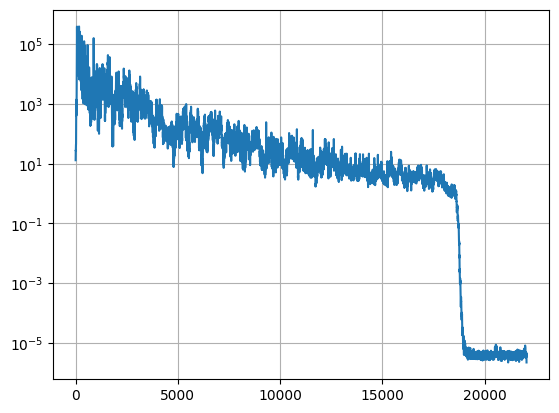

In [34]:
s, f = psd(data[:, 0], Fs=samplerate, NFFT=2**15, noverlap=2**14, detrend=detrend_none)
figure(1)
semilogy(f, s)
#xlim([0, 10])
#ylim([0,100])
grid()
s

In [35]:
len(f) # NFFT//2 + 1

16385

In [36]:
from scipy.signal import welch

f, s = welch(
    data[:, 0],
    fs=samplerate,
    window='hann',
    nperseg=2**15,
    noverlap=2**14,
    detrend=False,
    nfft=2**15,          # matches pad_to = NFFT
    return_onesided=True,
    scaling='density'    # ensures V^2/Hz
)
s

array([1.3105723e+01, 2.3993275e+01, 2.4866520e+01, ..., 3.8519356e-06,
       4.2773772e-06, 2.2273782e-06], dtype=float32)

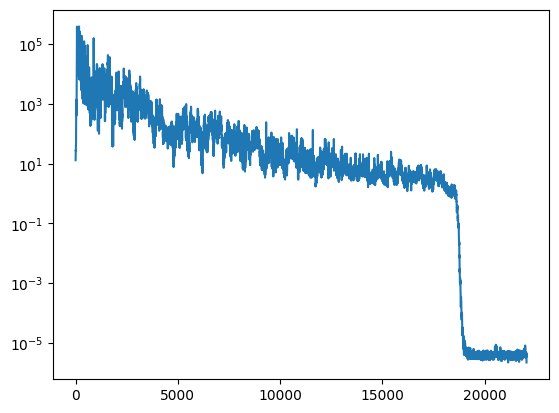

In [37]:
semilogy(f, s)

[1.3105723e+01 2.3993275e+01 2.4866520e+01 ... 3.8519356e-06 4.2773772e-06
 2.2273782e-06] [0.00000000e+00 3.40120625e+04 1.65266297e+05 6.44871914e+04
 6.82736094e+04 5.66429102e+04 2.78621816e+04 2.57531367e+04
 1.64401758e+04 1.87071465e+04 2.27599531e+04 6.37076758e+03
 8.03988135e+03 9.14491797e+03 1.05469414e+04 5.38832324e+03
 3.32532275e+03 1.60508289e+03 2.13451636e+03 2.46232666e+03
 1.03656084e+04 8.09779932e+03 2.32309741e+03 5.40569092e+03
 8.08889844e+03 2.64515112e+03 2.25424414e+03 2.56276294e+03
 1.93995874e+03 4.59573486e+03 6.03193311e+03 1.25195801e+04
 5.78519775e+03 3.83268823e+03 3.08722339e+03 3.81550903e+03
 7.33067236e+03 9.81129590e+03 6.15482861e+03 9.49530371e+03
 3.69297461e+03 2.68776709e+03 5.03021759e+02 7.68125427e+02
 1.08727197e+03 1.97176282e+03 6.19230908e+03 4.22030762e+03
 3.13241431e+03 4.70174805e+03 8.88579041e+02 2.33254785e+03
 1.03463489e+03 1.00321356e+03 3.15739307e+03 6.09360645e+03
 2.54323755e+03 3.80342041e+03 5.37019385e+03 2.2113620

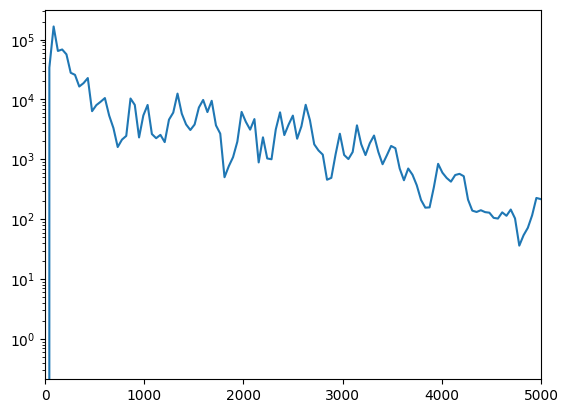

In [38]:
freq, Pxx = signal.welch(data[:, 0], fs=samplerate, nperseg=2**10, noverlap=2**9, window='box', detrend='constant')
semilogy(freq, Pxx)
#semilogy(f, s)
xlim([0, 5000])
print(s, Pxx)
print(len(s), len(Pxx))

## Parseval theorem


$$
\int_{-\infty}^{\infty} |x(t)|^2 \, dt
=
\int_{-\infty}^{\infty} |X(f)|^2 \, df
$$
$$
\sum_{n=0}^{N-1} |x[n]|^2
=
\frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2
$$

In [39]:
### Using FFT
import numpy as np

x = data[:, 0].astype(float)
N = len(x)

#------------------------------------------------------------
# Time-domain energy
#------------------------------------------------------------
E_time = np.sum(np.abs(x)**2)

#------------------------------------------------------------
# Frequency-domain energy
#------------------------------------------------------------
X = np.fft.fft(x)

E_freq = (1.0 / N) * np.sum(np.abs(X)**2)

E_time,  E_freq

(30347298816264.0, 30347298816264.004)

In [40]:
### Using power spectral density

import numpy as np

x = data[:, 0].astype(float)
N = len(x)

# ------------------------------------------------------------
# Time-domain average power
# ------------------------------------------------------------
P_time = np.mean(np.abs(x)**2)

# ------------------------------------------------------------
# PSD from your routine
# no detrend, no window, no padding, no overlap
# ------------------------------------------------------------
s, f = psd(
    x,
    Fs=samplerate,
    NFFT=N,
    noverlap=0,
    detrend=detrend_none,
    window=ones(N),
    pad_to=N
)

# ------------------------------------------------------------
# Frequency-domain power from PSD
# ------------------------------------------------------------
P_freq_sum = np.sum(s) * (f[1] - f[0])

P_time, P_freq_sum

(34407368.272408165, 34407368.27240818)

In [41]:
f, s = welch(
    x,
    fs=samplerate,
    window='boxcar',
    nperseg=N,
    noverlap=0,
    detrend=False,
    nfft=N,          # matches pad_to = NFFT
    return_onesided=True,
    scaling='density'    # ensures V^2/Hz
)
P_freq_sum = np.sum(s) * (f[1] - f[0])
P_time, P_freq_sum

(34407368.272408165, 34407368.27240818)